# 0. 미션 개요

이번 미션은 기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트입니다. 

각 모델을 구현하고 학습시키며, 성능을 비교 분석해 보세요.


# 1. 기본 설정

In [ ]:
# Google Drive를 마운트
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!apt-get install -y mecab mecab-ipadic-utf8 libmecab-dev
!pip install konlpy kiwipiepy sacrebleu

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libmecab2 mecab-ipadic mecab-utils
The following NEW packages will be installed:
  libmecab-dev libmecab2 mecab mecab-ipadic mecab-ipadic-utf8 mecab-utils
0 upgraded, 6 newly installed, 0 to remove and 42 not upgraded.
Need to get 7,367 kB of archives.
After this operation, 59.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab2 amd64 0.996-14build9 [199 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab-dev amd64 0.996-14build9 [306 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 mecab-utils amd64 0.996-14build9 [4,850 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 mecab-ipadic all 2.7.0-20070801+main-3 [6,718 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mecab amd64 0.996-14build9 [136 kB]
Get:6 http://archive.ubuntu.co

In [3]:
# 라이브러리
import os
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.tokenize import word_tokenize
from kiwipiepy import Kiwi
import sacrebleu

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cuda


In [5]:
# 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 2. 데이터 로드


In [6]:
train_json_file_path = '/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_train_set.json'
valid_json_file_path = '/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_valid_set.json'

with open(train_json_file_path, 'r', encoding='utf-8') as f:
    full_train_data = json.load(f)['data']

with open(valid_json_file_path, 'r', encoding='utf-8') as f:
    full_valid_data = json.load(f)['data']

TRAIN_COUNT = 60000
VALID_COUNT = 3000

data_train = full_train_data[:TRAIN_COUNT]
data_valid = full_valid_data[:VALID_COUNT]  

print(f"사용 train 개수: {len(data_train)}")
print(f"사용 valid 개수: {len(data_valid)}")

사용 train 개수: 60000
사용 valid 개수: 3000


# 3. 토큰화 및 길이 분석

[Korean]
 p50: 14.00
 p90: 25.00
 p95: 29.00
 p97: 32.00
 p99: 38.00
 최대: 123
 평균: 14.75
[English]
 p50: 11.00
 p90: 20.00
 p95: 23.00
 p97: 25.00
 p99: 30.00
 최대: 68
 평균: 11.68


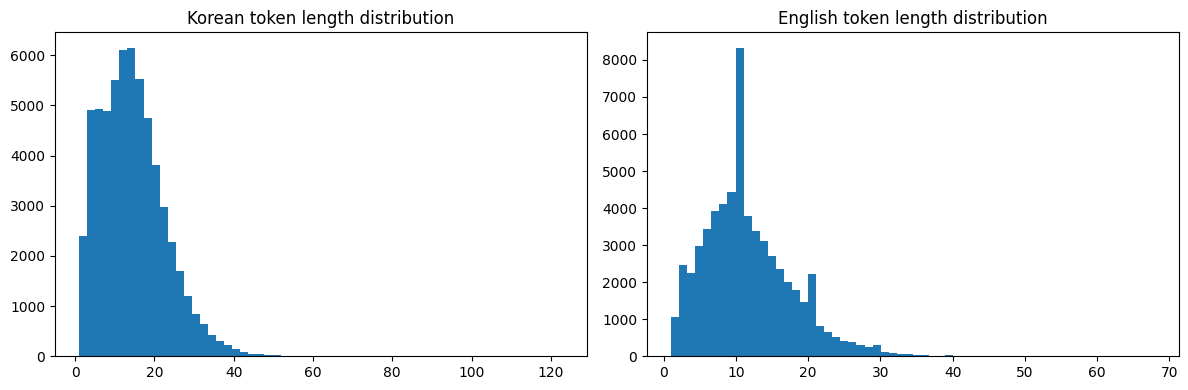

auto_max_len: 40
final MAX_LENGTH: 50


In [7]:
# Kiwi 객체 생성
kiwi = Kiwi()

# 한국어 토큰화 함수
def tokenizer_ko(text):
    return [token.form for token in kiwi.tokenize(text)]

# 영어 토큰화 함수
def tokenizer_en(text):
    return word_tokenize(text)

# train / valid 문장을 각각 한국어와 영어로 분리
ko_train = [x['ko'] for x in data_train]
en_train = [x['mt'] for x in data_train]
ko_valid = [x['ko'] for x in data_valid]
en_valid = [x['mt'] for x in data_valid]

# 길이 통계를 보기 위한 함수
def get_length_stats(lengths, name):
    print(f"[{name}]")
    for p in [50, 90, 95, 97, 99]:
        print(f" p{p}: {np.percentile(lengths, p):.2f}")
    print(f" 최대: {np.max(lengths)}")
    print(f" 평균: {np.mean(lengths):.2f}")

# 한국어/영어 토큰 길이 
ko_lengths = [len(tokenizer_ko(s)) for s in ko_train]
en_lengths = [len(tokenizer_en(s)) for s in en_train]

# 길이 분포 통계 출력 
get_length_stats(ko_lengths, "Korean")
get_length_stats(en_lengths, "English")

# 길이 분포를 히스토그램으로 시각화 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(ko_lengths, bins=60)
plt.title("Korean token length distribution")

plt.subplot(1,2,2)
plt.hist(en_lengths, bins=60)
plt.title("English token length distribution")
plt.tight_layout()
plt.show()

# 99 percentile 길이를 기반으로 자동 길이 
auto_max_len = max(
    int(np.percentile(ko_lengths, 99)),
    int(np.percentile(en_lengths, 99))
) + 2  # SOS, EOS 포함

# auto_max_len이 너무 작게 나오더라도 최소 50 
MAX_LENGTH = max(auto_max_len, 50)

print("auto_max_len:", auto_max_len)
print("final MAX_LENGTH:", MAX_LENGTH)

In [8]:
# 한국어-영어 문장쌍
pairs_train_raw = list(zip(ko_train, en_train))
pairs_valid_raw = list(zip(ko_valid, en_valid))

# 길이 제한을 넘는 문장은 제거
def length_ok(src, tgt, max_length):
    return len(tokenizer_ko(src)) <= (max_length - 2) and len(tokenizer_en(tgt)) <= (max_length - 2)

# 길이 조건을 만족하는 문장쌍
pairs_train = [p for p in pairs_train_raw if length_ok(p[0], p[1], MAX_LENGTH)]
pairs_valid = [p for p in pairs_valid_raw if length_ok(p[0], p[1], MAX_LENGTH)]

print("원본 train:", len(pairs_train_raw))
print("필터링 후 train:", len(pairs_train))
print("원본 valid:", len(pairs_valid_raw))
print("필터링 후 valid:", len(pairs_valid))

원본 train: 60000
필터링 후 train: 59916
원본 valid: 3000
필터링 후 valid: 2996


# 4. Vocabulary 구축

In [9]:
# 특수 토큰 id를 고정합니다.
SOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3

SPECIAL = {
    'SOS': SOS_token,
    'EOS': EOS_token,
    'PAD': PAD_token,
    '<unk>': UNK_token,
}

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = dict(SPECIAL)
        self.index2word = {v: k for k, v in SPECIAL.items()}
        self.n_words = 4  

    # 새로운 단어를 vocab에 추가
    def add_word(self, w):
        if w not in self.word2index:
            self.word2index[w] = self.n_words
            self.index2word[self.n_words] = w
            self.n_words += 1

# 문장쌍으로부터 vocab을 만듭니다.
# min_freq보다 적게 등장한 단어는 제외
def build_lang(pairs, side='src', min_freq=1):
    lang = Lang('ko' if side == 'src' else 'en')
    counter = Counter()

    for src, tgt in pairs:
        tokens = tokenizer_ko(src) if side == 'src' else tokenizer_en(tgt)
        counter.update(tokens)

    for w, cnt in counter.items():
        if cnt >= min_freq:
            lang.add_word(w)

    return lang, counter

# 입력 vocab은 2회 이상 등장한 단어만 사용
input_lang, input_counter = build_lang(pairs_train, side='src', min_freq=2)

# 출력 vocab은 희귀 단어도 최대한 살리기 위해 1회 이상 모두 사용
output_lang, output_counter = build_lang(pairs_train, side='tgt', min_freq=1)

print("입력 vocab:", input_lang.n_words)
print("출력 vocab:", output_lang.n_words)

입력 vocab: 11643
출력 vocab: 23475


# 5. Dataset / DataLoader

In [10]:
# 문장을 숫자 id 시퀀스로 바꾸기
def encode_sentence(sentence, tokenizer, word2index, max_length):
    ids = [word2index.get(tok, UNK_token) for tok in tokenizer(sentence)]
    ids = ids[:max_length-2]  # 너무 길면 자르기
    return torch.tensor([SOS_token] + ids + [EOS_token], dtype=torch.long)

# 문장쌍 데이터셋 클래스
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.data = []
        for src, tgt in pairs:
            src_ids = encode_sentence(src, tokenizer_ko, input_lang.word2index, MAX_LENGTH)
            tgt_ids = encode_sentence(tgt, tokenizer_en, output_lang.word2index, MAX_LENGTH)
            self.data.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# batch 내부 문장 길이가 다르기 때문에 padding을 위한 collate 함수를 따로 정의합니다.
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    # 각 문장의 실제 길이를 따로 저장합니다.
    src_lengths = torch.tensor([len(x) for x in src_batch], dtype=torch.long)
    tgt_lengths = torch.tensor([len(x) for x in tgt_batch], dtype=torch.long)

    # 가장 긴 문장 길이에 맞춰 PAD 토큰을 추가합니다.
    src_pad = pad_sequence(src_batch, batch_first=True, padding_value=PAD_token)
    tgt_pad = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_token)

    return src_pad, src_lengths, tgt_pad, tgt_lengths

# 실제 dataset을 만듭니다.
train_dataset = TranslationDataset(pairs_train)
valid_dataset = TranslationDataset(pairs_valid)

print("train_dataset:", len(train_dataset))
print("valid_dataset:", len(valid_dataset))

train_dataset: 59916
valid_dataset: 2996


# 6. 모델 정의

In [11]:
# 단방향 GRU 인코더입니다.
class EncoderRNN(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src, src_lengths=None):
        emb = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(emb)
        return outputs, hidden

# 양방향 GRU 인코더입니다.
# use_packed=True일 때 packed sequence를 사용하여 PAD 영향을 줄입니다.
class BiEncoderRNN(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, num_layers=2, dropout=0.3, use_packed=True):
        super().__init__()
        self.use_packed = use_packed
        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embed_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_outputs = nn.Linear(hidden_size * 2, hidden_size)
        self.fc_hidden = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, src, src_lengths=None):
        emb = self.dropout(self.embedding(src))

        # packed sequence를 사용하면 PAD 토큰 쪽 계산을 줄일 수 있습니다.
        if self.use_packed and src_lengths is not None:
            packed = pack_padded_sequence(emb, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
            outputs, hidden = self.gru(packed)
            outputs, _ = pad_packed_sequence(outputs, batch_first=True, padding_value=PAD_token)
        else:
            outputs, hidden = self.gru(emb)

        # 양방향 출력을 다시 hidden_size 차원으로 줄입니다.
        outputs = self.fc_outputs(outputs)

        # 마지막 forward/backward hidden을 합쳐 최종 hidden으로 만듭니다.
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
        hidden0 = torch.tanh(self.fc_hidden(hidden_cat)).unsqueeze(0)

        return outputs, hidden0

# 기본 GRU 디코더입니다.
class PlainDecoderRNN(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    # 한 스텝씩 디코딩할 때 사용하는 함수입니다.
    def forward_step(self, input_token, hidden):
        emb = self.dropout(self.embedding(input_token))
        output, hidden = self.gru(emb, hidden)
        output = self.out(output)
        return output, hidden

    # 학습 시에는 정답 시퀀스를 shift해서 한 번에 넣습니다.
    def forward_train(self, encoder_outputs, encoder_hidden, decoder_input_tokens, src_mask=None):
        hidden = encoder_hidden
        emb = self.dropout(self.embedding(decoder_input_tokens))
        outputs, hidden = self.gru(emb, hidden)
        outputs = self.out(outputs)
        return F.log_softmax(outputs, dim=-1), hidden

    # 추론 시에는 greedy decoding을 수행합니다.
    def forward_greedy(self, encoder_outputs, encoder_hidden, max_length, src_mask=None):
        batch_size = encoder_hidden.size(1)
        hidden = encoder_hidden
        decoder_input = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=encoder_hidden.device)
        outputs = []

        for _ in range(max_length - 1):
            output, hidden = self.forward_step(decoder_input, hidden)
            output = F.log_softmax(output, dim=-1)
            outputs.append(output)
            decoder_input = output.argmax(dim=-1).detach()

        return torch.cat(outputs, dim=1), hidden, None

# Bahdanau Attention 계산 클래스입니다.
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys, mask=None):
        # attention score를 계산합니다.
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys))).squeeze(2).unsqueeze(1)

        # PAD 위치는 attention에서 제외합니다.
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1) == 0, -1e9)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights

# Attention이 포함된 디코더입니다.
class AttnDecoderRNN(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(embed_size + hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    # 한 step 디코딩합니다.
    def forward_step(self, input_token, hidden, encoder_outputs, src_mask=None):
        emb = self.dropout(self.embedding(input_token))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs, mask=src_mask)
        gru_input = torch.cat((emb, context), dim=2)
        output, hidden = self.gru(gru_input, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

    # 학습 시에는 정답 시퀀스를 한 칸 shift해서 teacher forcing 형태로 넣습니다.
    def forward_train(self, encoder_outputs, encoder_hidden, decoder_input_tokens, src_mask=None):
        hidden = encoder_hidden
        outputs = []

        for t in range(decoder_input_tokens.size(1)):
            step_input = decoder_input_tokens[:, t].unsqueeze(1)
            output, hidden, _ = self.forward_step(step_input, hidden, encoder_outputs, src_mask)
            outputs.append(output)

        outputs = torch.cat(outputs, dim=1)
        return F.log_softmax(outputs, dim=-1), hidden

    # greedy decoding으로 추론합니다.
    def forward_greedy(self, encoder_outputs, encoder_hidden, max_length, src_mask=None):
        batch_size = encoder_outputs.size(0)
        hidden = encoder_hidden
        decoder_input = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=encoder_outputs.device)
        outputs = []
        attentions = []

        for _ in range(max_length - 1):
            output, hidden, attn_weights = self.forward_step(decoder_input, hidden, encoder_outputs, src_mask)
            output = F.log_softmax(output, dim=-1)
            outputs.append(output)
            attentions.append(attn_weights)
            decoder_input = output.argmax(dim=-1).detach()

        return torch.cat(outputs, dim=1), hidden, torch.cat(attentions, dim=1)
    
# 실험별 batch_size를 따로 적용할 수 있도록 dataloader 생성 함수를 분리합니다.
def build_dataloaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )
    return train_loader, valid_loader    

# 7. 학습 / 평가 함수

In [12]:
# source 문장에서 PAD가 아닌 위치만 1로 표시하는 mask를 만듭니다.
def make_src_mask(src):
    return (src != PAD_token).long()


# 1 epoch 학습/검증 함수입니다.
def run_epoch(loader, encoder, decoder, criterion, encoder_optimizer=None, decoder_optimizer=None,
              grad_clip=1.0, train=True):
    if train:
        encoder.train()
        decoder.train()
    else:
        encoder.eval()
        decoder.eval()

    total_loss = 0.0

    for src, src_lengths, tgt, tgt_lengths in loader:
        src = src.to(device)
        src_lengths = src_lengths.to(device)
        tgt = tgt.to(device)

        # 디코더 입력과 정답을 한 칸 shift해서 만듭니다.
        decoder_input = tgt[:, :-1]
        decoder_target = tgt[:, 1:]

        if train:
            encoder_optimizer.zero_grad()
            decoder_optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            encoder_outputs, encoder_hidden = encoder(src, src_lengths)
            src_mask = make_src_mask(src[:, :encoder_outputs.size(1)])

            decoder_outputs, _ = decoder.forward_train(
                encoder_outputs, encoder_hidden, decoder_input, src_mask
            )

            # PAD 토큰은 loss에서 제외합니다.
            loss = criterion(
                decoder_outputs.reshape(-1, decoder_outputs.size(-1)),
                decoder_target.reshape(-1)
            )

            if train:
                loss.backward()

                # gradient explosion을 막기 위해 gradient clipping 적용
                torch.nn.utils.clip_grad_norm_(encoder.parameters(), grad_clip)
                torch.nn.utils.clip_grad_norm_(decoder.parameters(), grad_clip)

                encoder_optimizer.step()
                decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# 전체 학습 함수입니다.
def train_model(train_loader, valid_loader, encoder, decoder, cfg):
    # optimizer 정의
    encoder_optimizer = optim.Adam(
        encoder.parameters(),
        lr=cfg['lr'],
        weight_decay=cfg.get('weight_decay', 0.0)
    )
    decoder_optimizer = optim.Adam(
        decoder.parameters(),
        lr=cfg['lr'],
        weight_decay=cfg.get('weight_decay', 0.0)
    )

    # scheduler는 실험에 따라 켜고 끌 수 있게 둡니다.
    scheduler_enc = None
    scheduler_dec = None
    if cfg.get('use_scheduler', False):
        scheduler_enc = optim.lr_scheduler.ReduceLROnPlateau(
            encoder_optimizer, mode='min', factor=0.5, patience=2
        )
        scheduler_dec = optim.lr_scheduler.ReduceLROnPlateau(
            decoder_optimizer, mode='min', factor=0.5, patience=2
        )

    criterion = nn.NLLLoss(ignore_index=PAD_token)

    history = {'train_loss': [], 'valid_loss': []}
    best_valid_loss = float('inf')
    best_encoder_state = None
    best_decoder_state = None
    patience_counter = 0

    for epoch in range(1, cfg['n_epochs'] + 1):
        train_loss = run_epoch(
            train_loader, encoder, decoder, criterion,
            encoder_optimizer, decoder_optimizer,
            grad_clip=cfg['grad_clip'], train=True
        )
        valid_loss = run_epoch(
            valid_loader, encoder, decoder, criterion,
            None, None,
            grad_clip=cfg['grad_clip'], train=False
        )

        # scheduler가 있으면 validation loss 기준으로 lr 조절
        if scheduler_enc is not None:
            scheduler_enc.step(valid_loss)
            scheduler_dec.step(valid_loss)

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)

        current_lr = encoder_optimizer.param_groups[0]['lr']
        print(f"[{cfg['experiment']}] Epoch {epoch:02d}/{cfg['n_epochs']} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | lr={current_lr:.6f}")

        # 가장 좋은 validation loss 모델을 저장합니다.
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
            best_decoder_state = {k: v.cpu().clone() for k, v in decoder.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # patience만큼 개선이 없으면 조기 종료
        if patience_counter >= cfg['patience']:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # 가장 좋았던 모델 가중치를 복원합니다.
    if best_encoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
        decoder.load_state_dict(best_decoder_state)

    return history, best_valid_loss

# 학습 곡선 시각화 함수
def plot_history(history, title='history'):
    plt.figure(figsize=(6,4))
    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['valid_loss'], label='valid_loss')
    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

# id 시퀀스를 다시 단어 시퀀스로 바꾸는 함수입니다.
def decode_ids_to_words(ids, index2word):
    words = []
    for idx in ids:
        if idx == EOS_token:
            break
        if idx in [SOS_token, PAD_token]:
            continue
        words.append(index2word.get(idx, '<unk>'))
    return words

# greedy decoding 함수입니다.
def eval_greedy(encoder, decoder, sentence):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        src = encode_sentence(sentence, tokenizer_ko, input_lang.word2index, MAX_LENGTH).unsqueeze(0).to(device)
        src_lengths = torch.tensor([src.size(1)], dtype=torch.long, device=device)

        encoder_outputs, encoder_hidden = encoder(src, src_lengths)
        src_mask = make_src_mask(src[:, :encoder_outputs.size(1)])

        decoder_outputs, _, _ = decoder.forward_greedy(
            encoder_outputs, encoder_hidden, MAX_LENGTH, src_mask
        )
        pred_ids = decoder_outputs.argmax(dim=-1).squeeze(0).tolist()
        return decode_ids_to_words(pred_ids, output_lang.index2word)

# beam search decoding 함수입니다.
def eval_beam(encoder, decoder, sentence, beam_width=4):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        src = encode_sentence(sentence, tokenizer_ko, input_lang.word2index, MAX_LENGTH).unsqueeze(0).to(device)
        src_lengths = torch.tensor([src.size(1)], dtype=torch.long, device=device)

        encoder_outputs, encoder_hidden = encoder(src, src_lengths)
        src_mask = make_src_mask(src[:, :encoder_outputs.size(1)])

        beams = [([SOS_token], 0.0, encoder_hidden)]

        for _ in range(MAX_LENGTH - 1):
            new_beams = []

            for seq, score, hidden in beams:
                if seq[-1] == EOS_token:
                    new_beams.append((seq, score, hidden))
                    continue

                input_tok = torch.tensor([[seq[-1]]], dtype=torch.long, device=device)
                output, next_hidden, _ = decoder.forward_step(input_tok, hidden, encoder_outputs, src_mask)
                log_probs = F.log_softmax(output, dim=-1).squeeze(0).squeeze(0)

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width)

                for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_seq = seq + [idx]
                    new_score = score + lp
                    new_beams.append((new_seq, new_score, next_hidden))

            # 길이가 긴 문장이 무조건 불리하지 않도록 간단한 length normalization 적용
            beams = sorted(
                new_beams,
                key=lambda x: x[1] / (len(x[0]) ** 0.7),
                reverse=True
            )[:beam_width]

            if all(seq[-1] == EOS_token for seq, _, _ in beams):
                break

        best_seq = beams[0][0][1:]
        return decode_ids_to_words(best_seq, output_lang.index2word)

# sacreBLEU를 계산합니다.
def calculate_sacrebleu(encoder, decoder, evaluation_pairs, beam_width=1):
    preds = []
    refs = []

    for src, tgt in evaluation_pairs:
        pred_tokens = eval_greedy(encoder, decoder, src) if beam_width == 1 else eval_beam(encoder, decoder, src, beam_width=beam_width)
        pred_text = ' '.join(pred_tokens)
        ref_text = ' '.join(tokenizer_en(tgt))
        preds.append(pred_text)
        refs.append(ref_text)

    bleu = sacrebleu.corpus_bleu(preds, [refs])
    return bleu.score

# 랜덤 샘플 예측 결과를 보여주는 함수입니다.
def show_random_predictions(encoder, decoder, pairs, n=5, beam_width=1):
    for _ in range(n):
        src, tgt = random.choice(pairs)
        pred_tokens = eval_greedy(encoder, decoder, src) if beam_width == 1 else eval_beam(encoder, decoder, src, beam_width=beam_width)
        print('>', src)
        print('=', tgt)
        print('<', ' '.join(pred_tokens))
        print()

# cfg에 맞춰 encoder / decoder를 생성합니다.
def build_model(cfg):
    if cfg['encoder_type'] == 'gru':
        encoder = EncoderRNN(
            input_lang.n_words,
            cfg['embed_size'],
            cfg['hidden_size'],
            dropout=cfg['dropout']
        ).to(device)
    else:
        encoder = BiEncoderRNN(
            input_lang.n_words,
            cfg['embed_size'],
            cfg['hidden_size'],
            num_layers=cfg['num_layers'],
            dropout=cfg['dropout'],
            use_packed=cfg['use_packed']
        ).to(device)

    if cfg['decoder_type'] == 'plain':
        decoder = PlainDecoderRNN(
            output_lang.n_words,
            cfg['embed_size'],
            cfg['hidden_size'],
            dropout=cfg['dropout']
        ).to(device)
    else:
        decoder = AttnDecoderRNN(
            output_lang.n_words,
            cfg['embed_size'],
            cfg['hidden_size'],
            dropout=cfg['dropout']
        ).to(device)

    return encoder, decoder

# 하나의 실험 전체를 실행하는 함수입니다.
def run_experiment(cfg):
    set_seed(cfg.get('seed', 42))

    # 실험별 batch_size로 dataloader를 새로 만듭니다.
    train_loader, valid_loader = build_dataloaders(cfg['batch_size'])

    # 모델 생성
    encoder, decoder = build_model(cfg)

    # 학습
    history, best_valid_loss = train_model(train_loader, valid_loader, encoder, decoder, cfg)

    # loss 그래프 출력
    plot_history(history, cfg['experiment'])

    # BLEU 평가
    bleu = calculate_sacrebleu(
        encoder,
        decoder,
        pairs_valid,
        beam_width=cfg['beam_width']
    )

    print(f"{cfg['experiment']} best_valid_loss: {best_valid_loss:.4f}")
    print(f"{cfg['experiment']} sacreBLEU: {bleu:.4f}")

    # 랜덤 예시 출력
    show_random_predictions(encoder, decoder, pairs_valid, n=5, beam_width=cfg['beam_width'])

    # 결과를 표 형태로 정리하기 쉽게 dict로 반환
    result = {
        'experiment': cfg['experiment'],
        'encoder_type': cfg['encoder_type'],
        'decoder_type': cfg['decoder_type'],
        'embed_size': cfg['embed_size'],
        'hidden_size': cfg['hidden_size'],
        'num_layers': cfg['num_layers'],
        'dropout': cfg['dropout'],
        'lr': cfg['lr'],
        'use_packed': cfg['use_packed'],
        'beam_width': cfg['beam_width'],
        'best_valid_loss': round(best_valid_loss, 4),
        'sacreBLEU': round(bleu, 4),
    }

    return encoder, decoder, history, result

# 8. 모델 비교

## - baseline_seq2seq

[baseline_seq2seq] Epoch 01/20 | train_loss=4.8765 | valid_loss=4.1872 | lr=0.001000
[baseline_seq2seq] Epoch 02/20 | train_loss=3.9354 | valid_loss=3.8787 | lr=0.001000
[baseline_seq2seq] Epoch 03/20 | train_loss=3.5421 | valid_loss=3.7376 | lr=0.001000
[baseline_seq2seq] Epoch 04/20 | train_loss=3.2664 | valid_loss=3.6613 | lr=0.001000
[baseline_seq2seq] Epoch 05/20 | train_loss=3.0517 | valid_loss=3.6446 | lr=0.001000
[baseline_seq2seq] Epoch 06/20 | train_loss=2.8729 | valid_loss=3.6108 | lr=0.001000
[baseline_seq2seq] Epoch 07/20 | train_loss=2.7216 | valid_loss=3.6116 | lr=0.001000
[baseline_seq2seq] Epoch 08/20 | train_loss=2.5958 | valid_loss=3.6177 | lr=0.001000
[baseline_seq2seq] Epoch 09/20 | train_loss=2.4867 | valid_loss=3.6261 | lr=0.001000
[baseline_seq2seq] Epoch 10/20 | train_loss=2.3923 | valid_loss=3.6325 | lr=0.001000
Early stopping triggered at epoch 10.


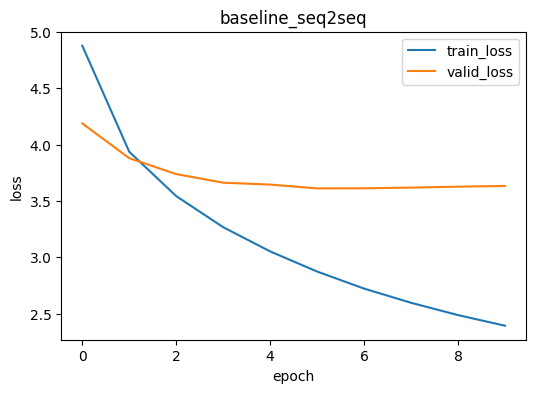

baseline_seq2seq best_valid_loss: 3.6108
baseline_seq2seq sacreBLEU: 4.2078
> >구미 여자.
= > Gumi woman.
< > It 's a little bit .

> 물리적 로봇이 산업, 블루칼라 직업을 빠르게 대체하고 있는 것과 같은 방식으로 소프트웨어 로봇은 화이트칼라 직업의 높은 비율을 대체하게 될 것이다.
= In the same way that physical robots are rapidly replacing industrial, blue-collar jobs, software robots will replace a high percentage of white-collar jobs.
< It is a multi-functional that can be used in conjunction , but it is a small amount of the most important nutrient for the first time .

> 뭘 주문하시겠어요?
= What would you like to order?
< What do you do n't do it , but you do n't worry , but it 's not possible .

> 아빠 내가 40살 되면 아빠는 몇 살이야?
= Dad, how old are you when I turn 40?
< What 's the difference between the two calculators ?

> 좋아요, 언제든지 저희에게 알려주세요.
= Okay, feel free to let us know.
< Okay , please let us know as soon as possible .



{'experiment': 'baseline_seq2seq',
 'encoder_type': 'gru',
 'decoder_type': 'plain',
 'embed_size': 256,
 'hidden_size': 256,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.001,
 'use_packed': False,
 'beam_width': 1,
 'best_valid_loss': 3.6108,
 'sacreBLEU': 4.2078}

In [ ]:
# 기본 seq2seq 실험
BASELINE_CFG = {
    'experiment': 'baseline_seq2seq',
    'encoder_type': 'gru',
    'decoder_type': 'plain',
    'embed_size': 256,
    'hidden_size': 256,
    'num_layers': 1,
    'dropout': 0.2,
    'lr': 0.0010,
    'batch_size': 64,
    'n_epochs': 20,
    'patience': 4,
    'grad_clip': 1.0,
    'use_packed': False,
    'use_scheduler': False,
    'beam_width': 1,
    'weight_decay': 0.0,
    'seed': 42,
}

# baseline_seq2seq 실험 실행
baseline_encoder, baseline_decoder, baseline_history, baseline_result = run_experiment(BASELINE_CFG)
baseline_result

## - attention_seq2seq
기본 Seq2Seq에 attention을 추가


[attention_seq2seq] Epoch 01/20 | train_loss=4.8208 | valid_loss=4.0578 | lr=0.001000
[attention_seq2seq] Epoch 02/20 | train_loss=3.7557 | valid_loss=3.6077 | lr=0.001000
[attention_seq2seq] Epoch 03/20 | train_loss=3.2610 | valid_loss=3.3996 | lr=0.001000
[attention_seq2seq] Epoch 04/20 | train_loss=2.9133 | valid_loss=3.2741 | lr=0.001000
[attention_seq2seq] Epoch 05/20 | train_loss=2.6395 | valid_loss=3.2018 | lr=0.001000
[attention_seq2seq] Epoch 06/20 | train_loss=2.4132 | valid_loss=3.1566 | lr=0.001000
[attention_seq2seq] Epoch 07/20 | train_loss=2.2258 | valid_loss=3.1287 | lr=0.001000
[attention_seq2seq] Epoch 08/20 | train_loss=2.0680 | valid_loss=3.1100 | lr=0.001000
[attention_seq2seq] Epoch 09/20 | train_loss=1.9383 | valid_loss=3.1070 | lr=0.001000
[attention_seq2seq] Epoch 10/20 | train_loss=1.8251 | valid_loss=3.1036 | lr=0.001000
[attention_seq2seq] Epoch 11/20 | train_loss=1.7321 | valid_loss=3.1091 | lr=0.001000
[attention_seq2seq] Epoch 12/20 | train_loss=1.6498 | 

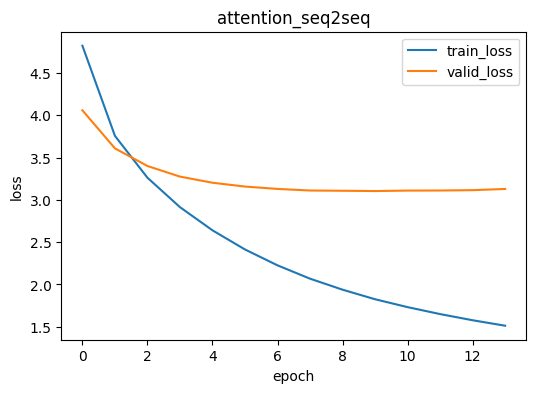

attention_seq2seq best_valid_loss: 3.1036
attention_seq2seq sacreBLEU: 13.2393
> >구미 여자.
= > Gumi woman.
< > Park Youngsun .

> 물리적 로봇이 산업, 블루칼라 직업을 빠르게 대체하고 있는 것과 같은 방식으로 소프트웨어 로봇은 화이트칼라 직업의 높은 비율을 대체하게 될 것이다.
= In the same way that physical robots are rapidly replacing industrial, blue-collar jobs, software robots will replace a high percentage of white-collar jobs.
< The innovative technology is like to be a large amount of procurement in the traditional network and how to be a huge sense of potential .

> 뭘 주문하시겠어요?
= What would you like to order?
< What do you order ?

> 아빠 내가 40살 되면 아빠는 몇 살이야?
= Dad, how old are you when I turn 40?
< If I live in my 20s , I am a lot of people in a few years old ?

> 좋아요, 언제든지 저희에게 알려주세요.
= Okay, feel free to let us know.
< Please let us know if you can feel us anytime .



{'experiment': 'attention_seq2seq',
 'encoder_type': 'gru',
 'decoder_type': 'attn',
 'embed_size': 256,
 'hidden_size': 256,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.001,
 'use_packed': False,
 'beam_width': 1,
 'best_valid_loss': 3.1036,
 'sacreBLEU': 13.2393}

In [14]:
ATTN_CFG = {
    'experiment': 'attention_seq2seq',
    'encoder_type': 'gru',
    'decoder_type': 'attn',
    'embed_size': 256,
    'hidden_size': 256,
    'num_layers': 1,
    'dropout': 0.2,
    'lr': 0.0010,
    'batch_size': 64,
    'n_epochs': 20,
    'patience': 4,
    'grad_clip': 1.0,
    'use_packed': False,
    'use_scheduler': False,
    'beam_width': 1,
    'weight_decay': 0.0,
    'seed': 42,
}

# attention_seq2seq 실험 실행
attn_encoder, attn_decoder, attn_history, attn_result = run_experiment(ATTN_CFG)
attn_result

## - bigru_attention
인코더를 양방향 GRU로 바꿔 반영


[bigru_attention] Epoch 01/20 | train_loss=4.7115 | valid_loss=3.9042 | lr=0.001000
[bigru_attention] Epoch 02/20 | train_loss=3.5927 | valid_loss=3.4734 | lr=0.001000
[bigru_attention] Epoch 03/20 | train_loss=3.0993 | valid_loss=3.2605 | lr=0.001000
[bigru_attention] Epoch 04/20 | train_loss=2.7534 | valid_loss=3.1482 | lr=0.001000
[bigru_attention] Epoch 05/20 | train_loss=2.4872 | valid_loss=3.0797 | lr=0.001000
[bigru_attention] Epoch 06/20 | train_loss=2.2723 | valid_loss=3.0451 | lr=0.001000
[bigru_attention] Epoch 07/20 | train_loss=2.0968 | valid_loss=3.0119 | lr=0.001000
[bigru_attention] Epoch 08/20 | train_loss=1.9500 | valid_loss=3.0020 | lr=0.001000
[bigru_attention] Epoch 09/20 | train_loss=1.8334 | valid_loss=3.0028 | lr=0.001000
[bigru_attention] Epoch 10/20 | train_loss=1.7338 | valid_loss=2.9959 | lr=0.001000
[bigru_attention] Epoch 11/20 | train_loss=1.6504 | valid_loss=3.0100 | lr=0.001000
[bigru_attention] Epoch 12/20 | train_loss=1.5782 | valid_loss=3.0090 | lr=0

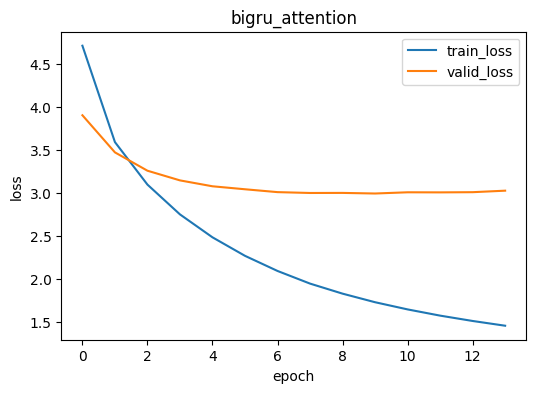

bigru_attention best_valid_loss: 2.9959
bigru_attention sacreBLEU: 16.2327
> >구미 여자.
= > Gumi woman.
< > Kim Jong Kook .

> 물리적 로봇이 산업, 블루칼라 직업을 빠르게 대체하고 있는 것과 같은 방식으로 소프트웨어 로봇은 화이트칼라 직업의 높은 비율을 대체하게 될 것이다.
= In the same way that physical robots are rapidly replacing industrial, blue-collar jobs, software robots will replace a high percentage of white-collar jobs.
< The software that can be carried out smoothly and enables high levels of the tidal flat .

> 뭘 주문하시겠어요?
= What would you like to order?
< What would you like to order ?

> 아빠 내가 40살 되면 아빠는 몇 살이야?
= Dad, how old are you when I turn 40?
< How many colors will be old old ?

> 좋아요, 언제든지 저희에게 알려주세요.
= Okay, feel free to let us know.
< OK , please let us know .



{'experiment': 'bigru_attention',
 'encoder_type': 'bigru',
 'decoder_type': 'attn',
 'embed_size': 256,
 'hidden_size': 256,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.001,
 'use_packed': False,
 'beam_width': 1,
 'best_valid_loss': 2.9959,
 'sacreBLEU': 16.2327}

In [15]:
BIGRU_CFG = {
    'experiment': 'bigru_attention',
    'encoder_type': 'bigru',
    'decoder_type': 'attn',
    'embed_size': 256,
    'hidden_size': 256,
    'num_layers': 1,
    'dropout': 0.2,
    'lr': 0.0010,
    'batch_size': 64,
    'n_epochs': 20,
    'patience': 4,
    'grad_clip': 1.0,
    'use_packed': False,
    'use_scheduler': False,
    'beam_width': 1,
    'weight_decay': 0.0,
    'seed': 42,
}

# bigru_attention 실험 실행
bigru_encoder, bigru_decoder, bigru_history, bigru_result = run_experiment(BIGRU_CFG)
bigru_result

## - bigru_attention_tuned
가장 성능이 좋았던 하이퍼파라미터값 반영


[bigru_attention_tuned] Epoch 01/30 | train_loss=4.7698 | valid_loss=4.0570 | lr=0.000700
[bigru_attention_tuned] Epoch 02/30 | train_loss=3.8000 | valid_loss=3.6044 | lr=0.000700
[bigru_attention_tuned] Epoch 03/30 | train_loss=3.2890 | valid_loss=3.3037 | lr=0.000700
[bigru_attention_tuned] Epoch 04/30 | train_loss=2.8884 | valid_loss=3.0932 | lr=0.000700
[bigru_attention_tuned] Epoch 05/30 | train_loss=2.5569 | valid_loss=2.9426 | lr=0.000700
[bigru_attention_tuned] Epoch 06/30 | train_loss=2.2765 | valid_loss=2.8415 | lr=0.000700
[bigru_attention_tuned] Epoch 07/30 | train_loss=2.0367 | valid_loss=2.7347 | lr=0.000700
[bigru_attention_tuned] Epoch 08/30 | train_loss=1.8350 | valid_loss=2.6832 | lr=0.000700
[bigru_attention_tuned] Epoch 09/30 | train_loss=1.6645 | valid_loss=2.6398 | lr=0.000700
[bigru_attention_tuned] Epoch 10/30 | train_loss=1.5192 | valid_loss=2.6125 | lr=0.000700
[bigru_attention_tuned] Epoch 11/30 | train_loss=1.3976 | valid_loss=2.5946 | lr=0.000700
[bigru_att

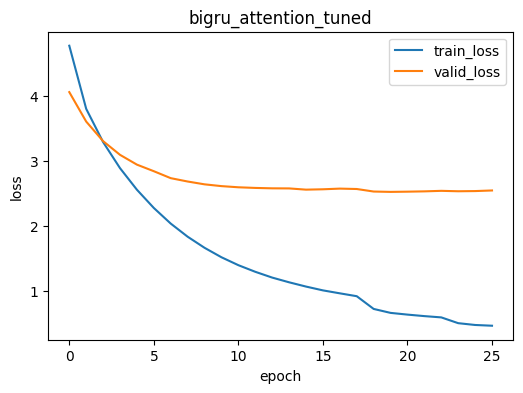

bigru_attention_tuned best_valid_loss: 2.5238
bigru_attention_tuned sacreBLEU: 23.6349
> >구미 여자.
= > Gumi woman.
< > Kim Jong Kook .

> 물리적 로봇이 산업, 블루칼라 직업을 빠르게 대체하고 있는 것과 같은 방식으로 소프트웨어 로봇은 화이트칼라 직업의 높은 비율을 대체하게 될 것이다.
= In the same way that physical robots are rapidly replacing industrial, blue-collar jobs, software robots will replace a high percentage of white-collar jobs.
< As a robot house , the software robot as a specific company is to run , and the health of the help of water will be the same .

> 뭘 주문하시겠어요?
= What would you like to order?
< What would you like to order ?

> 아빠 내가 40살 되면 아빠는 몇 살이야?
= Dad, how old are you when I turn 40?
< How old years old years old years ?

> 좋아요, 언제든지 저희에게 알려주세요.
= Okay, feel free to let us know.
< Okay , please feel free to let us know .



{'experiment': 'bigru_attention_tuned',
 'encoder_type': 'bigru',
 'decoder_type': 'attn',
 'embed_size': 256,
 'hidden_size': 512,
 'num_layers': 2,
 'dropout': 0.3,
 'lr': 0.0007,
 'use_packed': True,
 'beam_width': 4,
 'best_valid_loss': 2.5238,
 'sacreBLEU': 23.6349}

In [16]:
TUNED_CFG = {
    'experiment': 'bigru_attention_tuned',
    'encoder_type': 'bigru',
    'decoder_type': 'attn',
    'embed_size': 256,
    'hidden_size': 512,
    'num_layers': 2,
    'dropout': 0.3,
    'lr': 0.0007,
    'batch_size': 64,
    'n_epochs': 30,
    'patience': 6,
    'grad_clip': 1.0,
    'use_packed': True,
    'use_scheduler': True,
    'beam_width': 4,
    'weight_decay': 1e-5,
    'seed': 42,
}

# bigru_attention_tuned 실험 실행
tuned_encoder, tuned_decoder, tuned_history, tuned_result = run_experiment(TUNED_CFG)
tuned_result

## - bigru_attention_improved
개선 실험


[bigru_attention_improved] Epoch 01/35 | train_loss=4.8919 | valid_loss=4.1486 | lr=0.000500
[bigru_attention_improved] Epoch 02/35 | train_loss=3.8924 | valid_loss=3.6666 | lr=0.000500
[bigru_attention_improved] Epoch 03/35 | train_loss=3.3901 | valid_loss=3.3544 | lr=0.000500
[bigru_attention_improved] Epoch 04/35 | train_loss=3.0088 | valid_loss=3.1505 | lr=0.000500
[bigru_attention_improved] Epoch 05/35 | train_loss=2.6977 | valid_loss=2.9845 | lr=0.000500
[bigru_attention_improved] Epoch 06/35 | train_loss=2.4289 | valid_loss=2.8579 | lr=0.000500
[bigru_attention_improved] Epoch 07/35 | train_loss=2.1958 | valid_loss=2.7693 | lr=0.000500
[bigru_attention_improved] Epoch 08/35 | train_loss=1.9948 | valid_loss=2.6924 | lr=0.000500
[bigru_attention_improved] Epoch 09/35 | train_loss=1.8128 | valid_loss=2.6428 | lr=0.000500
[bigru_attention_improved] Epoch 10/35 | train_loss=1.6599 | valid_loss=2.6006 | lr=0.000500
[bigru_attention_improved] Epoch 11/35 | train_loss=1.5220 | valid_los

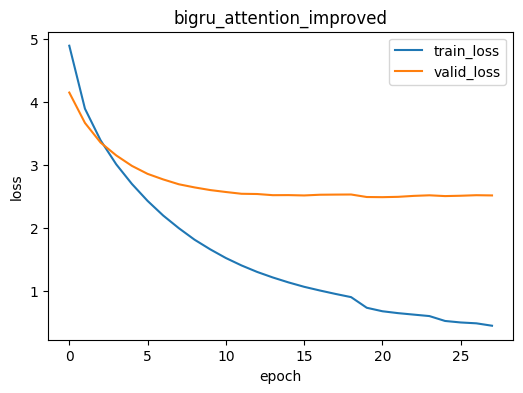

bigru_attention_improved best_valid_loss: 2.4879
bigru_attention_improved sacreBLEU: 24.9528
> >구미 여자.
= > Gumi woman.
< > A girl girl .

> 물리적 로봇이 산업, 블루칼라 직업을 빠르게 대체하고 있는 것과 같은 방식으로 소프트웨어 로봇은 화이트칼라 직업의 높은 비율을 대체하게 될 것이다.
= In the same way that physical robots are rapidly replacing industrial, blue-collar jobs, software robots will replace a high percentage of white-collar jobs.
< In the case of a system that moves a lot of money and a lot of money , the software robot is replaced by the high amount of a nation .

> 뭘 주문하시겠어요?
= What would you like to order?
< What do you want to order ?

> 아빠 내가 40살 되면 아빠는 몇 살이야?
= Dad, how old are you when I turn 40?
< What if I get 40 years old ?

> 좋아요, 언제든지 저희에게 알려주세요.
= Okay, feel free to let us know.
< OK , please feel free to let us know .



{'experiment': 'bigru_attention_improved',
 'encoder_type': 'bigru',
 'decoder_type': 'attn',
 'embed_size': 256,
 'hidden_size': 512,
 'num_layers': 2,
 'dropout': 0.3,
 'lr': 0.0005,
 'use_packed': True,
 'beam_width': 5,
 'best_valid_loss': 2.4879,
 'sacreBLEU': 24.9528}

In [17]:
IMP_CFG = {
    'experiment': 'bigru_attention_improved',
    'encoder_type': 'bigru',
    'decoder_type': 'attn',
    'embed_size': 256,
    'hidden_size': 512,
    'num_layers': 2,
    'dropout': 0.3,
    'lr': 0.0005,
    'batch_size': 64,
    'n_epochs': 35,
    'patience': 7,
    'grad_clip': 1.0,
    'use_packed': True,
    'use_scheduler': True,
    'beam_width': 5,
    'weight_decay': 1e-5,
    'seed': 42,
}

# bigru_attention_improved 실험 실행
imp_encoder, imp_decoder, imp_history, imp_result = run_experiment(IMP_CFG)
imp_result

## - 최종 결과표

In [18]:
results_df = pd.DataFrame([
    baseline_result,
    attn_result,
    bigru_result,
    tuned_result,
    imp_result
])
results_df

,experiment,encoder_type,decoder_type,embed_size,hidden_size,num_layers,dropout,lr,use_packed,beam_width,best_valid_loss,sacreBLEU
0,baseline_seq2seq,gru,plain,256,256,1,0.2,0.0010,False,1,3.6108,4.2078
1,attention_seq2seq,gru,attn,256,256,1,0.2,0.0010,False,1,3.1036,13.2393
2,bigru_attention,bigru,attn,256,256,1,0.2,0.0010,False,1,2.9959,16.2327
3,bigru_attention_tuned,bigru,attn,256,512,2,0.3,0.0007,True,4,2.5238,23.6349
4,bigru_attention_improved,bigru,attn,256,512,2,0.3,0.0005,True,5,2.4879,24.9528


# 9. 결론

### 최종 정리

이번 실험에서는 한영 기계 번역 성능 향상을 위해 기본 GRU Seq2Seq → Attention Seq2Seq → BiGRU + Attention → tuned BiGRU + Attention 순서로 모델 구조를 단계적으로 확장하였다.  
먼저 기본 GRU Seq2Seq를 기준 모델로 두고, 이후 attention을 추가했을 때 성능이 향상되는지 확인하였다. 그 다음 인코더를 BiGRU로 바꾸어 문장의 앞뒤 문맥을 함께 반영하도록 하였고, 마지막으로 packed sequence, scheduler, beam search, 더 큰 hidden size와 layer 수를 적용한 tuned 버전까지 확장하였다.

또한 이번 v7.1에서는 학습 데이터 사용량을 전체 train의 70%까지 확대하고, 문장 길이 제한도 기존보다 더 넉넉하게 설정하였다. 그 결과 더 다양한 문장 패턴을 학습할 수 있었고, 최종적으로 v7_bigru_attention_improved가 이전 tuned 버전보다 더 높은 번역 성능을 보이는지 확인할 수 있도록 구성하였다.

즉, 이번 실험은 단순히 마지막 고성능 모델만 제시한 것이 아니라,  
기본 구조에서 시작해 attention, 양방향 인코더, 학습 안정화 기법, decoding 개선까지 순차적으로 반영하며 성능을 끌어올린 과정**을 보여준다는 점에서 의미가 있다.
